In [172]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler


## Read Data

In [173]:
# Read Data
df = pd.read_csv("insurance.csv")
print(df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [174]:
# To check shape of dataset
print(f"Shape of dataset {df.shape}\n")

# Feature Name
print(f"Column name : {df.columns}\n")

# data types
print(f"Data type of dataset\n {df.dtypes}\n")

# Unique values
print("Unique values in each feature")
for i in df.columns:
    print(f"{i} : {df[i].nunique()}")

Shape of dataset (1338, 7)

Column name : Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

Data type of dataset
 age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Unique values in each feature
age : 47
sex : 2
bmi : 548
children : 6
smoker : 2
region : 4
charges : 1337


## Data Preprocessing

In [175]:
# concise summary
print(f"The concise summary of dataset : \n")
print(df.info())

The concise summary of dataset : 

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB
None


In [176]:
# statistical summary
print("The statistical summary of the dataset : \n")
print(df.describe(include='all'))

The statistical summary of the dataset : 

                age   sex          bmi     children smoker     region  \
count   1338.000000  1338  1338.000000  1338.000000   1338       1338   
unique          NaN     2          NaN          NaN      2          4   
top             NaN  male          NaN          NaN     no  southeast   
freq            NaN   676          NaN          NaN   1064        364   
mean      39.207025   NaN    30.663397     1.094918    NaN        NaN   
std       14.049960   NaN     6.098187     1.205493    NaN        NaN   
min       18.000000   NaN    15.960000     0.000000    NaN        NaN   
25%       27.000000   NaN    26.296250     0.000000    NaN        NaN   
50%       39.000000   NaN    30.400000     1.000000    NaN        NaN   
75%       51.000000   NaN    34.693750     2.000000    NaN        NaN   
max       64.000000   NaN    53.130000     5.000000    NaN        NaN   

             charges  
count    1338.000000  
unique           NaN  
top        

In [177]:
# Finding the missing value
print("Checking missing values in the dataset \n")
print(df.isnull().sum())

Checking missing values in the dataset 

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [178]:
# Finding the duplicate values
print("Finding the duplicate values \n")
print(df.duplicated().sum())

Finding the duplicate values 

1


In [179]:
# Dropping the duplicate value
df.drop_duplicates(inplace=True)
print(df.duplicated().sum())

0


   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


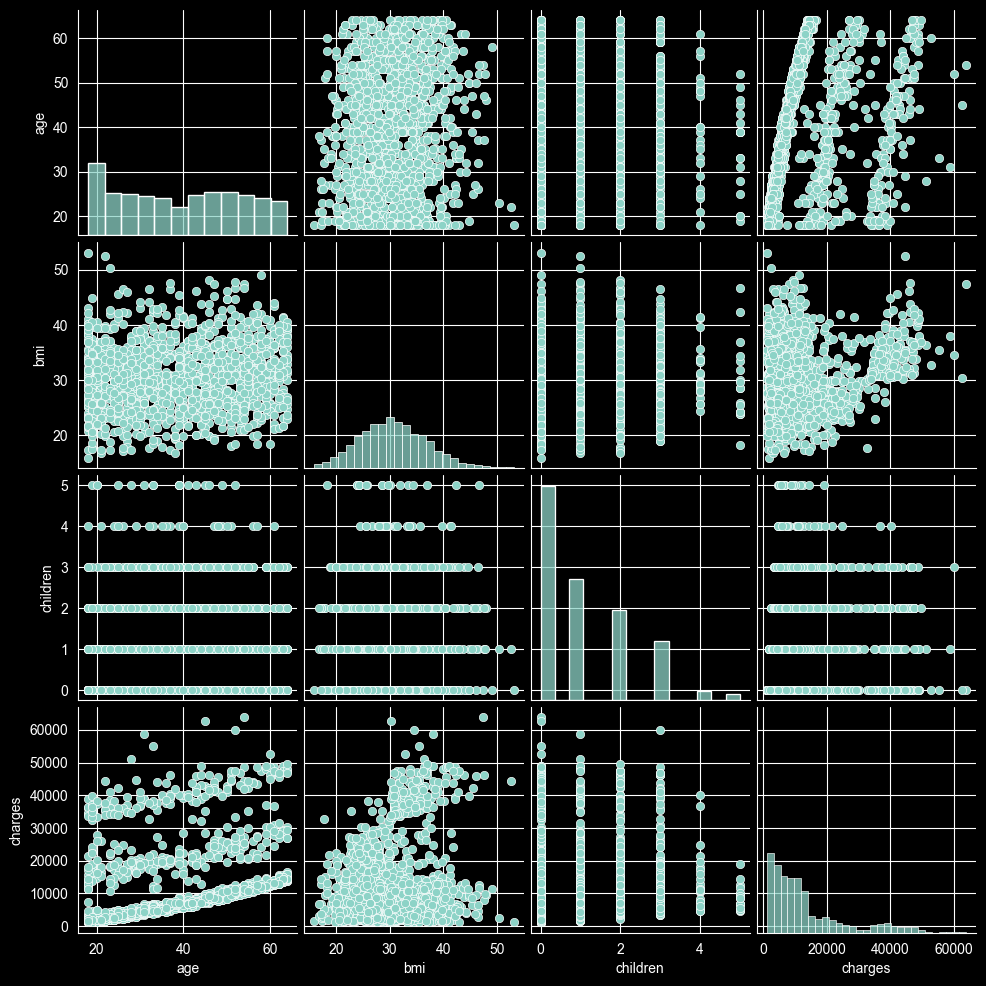

In [180]:
# Checking the Outliers
sns.pairplot(df)
print(df.head())

Text(0.5, 1.0, 'Boxplot for Age')

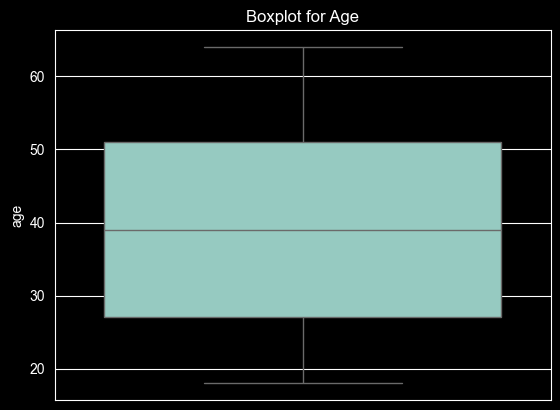

In [181]:
# Box plot
sns.boxplot(df['age'])
plt.title("Boxplot for Age")

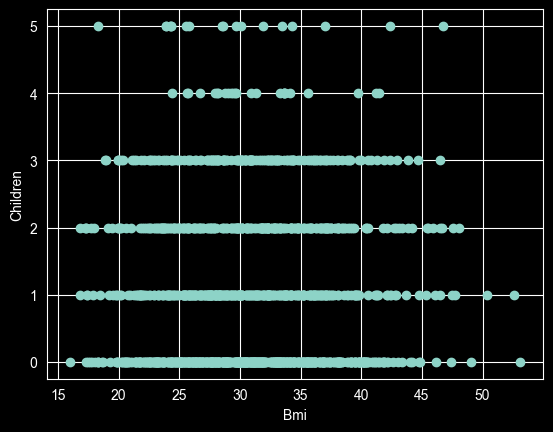

In [182]:
# Scatter plot
plt.scatter(df['bmi'], df['children'])
plt.xlabel("Bmi")
plt.ylabel("Children")
plt.show()

Text(0.5, 1.0, 'Bar Chart of BMI')

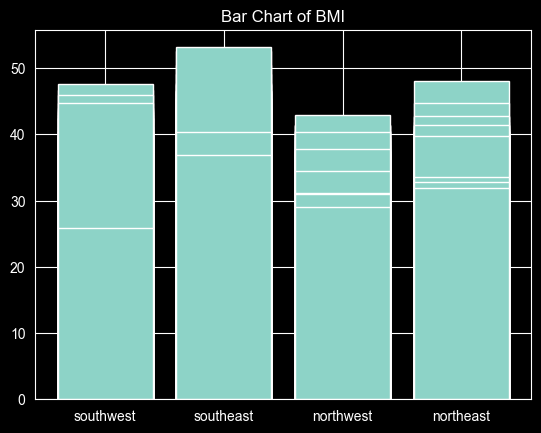

In [183]:
# Barplot
plt.bar(df['region'], df['bmi'])
plt.title("Bar Chart of BMI")

Text(0.5, 1.0, 'Bar Chart of BMI')

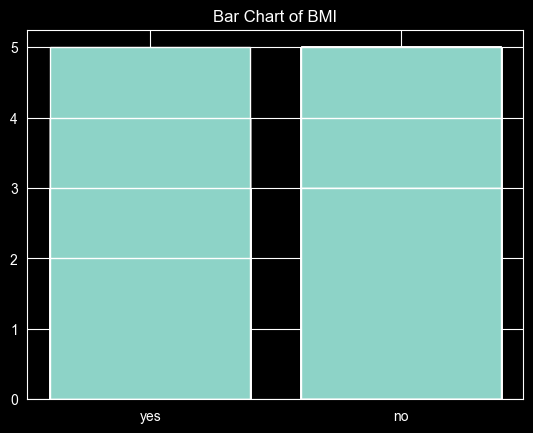

In [184]:
# Barplot
plt.bar(df['smoker'], df['children'])
plt.title("Bar Chart of BMI")

In [185]:
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
outliers = df[(df['bmi'] < lower_limit) | (df['bmi'] > upper_limit)]
print(Q1, Q3)
print(outliers)

26.29 34.7
      age     sex    bmi  children smoker     region      charges
116    58    male  49.06         0     no  southeast  11381.32540
286    46  female  48.07         2     no  northeast   9432.92530
401    47    male  47.52         1     no  southeast   8083.91980
543    54  female  47.41         0    yes  southeast  63770.42801
847    23    male  50.38         1     no  southeast   2438.05520
860    37  female  47.60         2    yes  southwest  46113.51100
1047   22    male  52.58         1    yes  southeast  44501.39820
1088   52    male  47.74         1     no  southeast   9748.91060
1317   18    male  53.13         0     no  southeast   1163.46270


In [186]:
Q1 = df['charges'].quantile(0.25)
Q3 = df['charges'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
outliers = df[(df['charges'] < lower_limit) | (df['charges'] > upper_limit)]
print(Q1, Q3)
print(outliers)

4746.344 16657.71745
      age     sex     bmi  children smoker     region      charges
14     27    male  42.130         0    yes  southeast  39611.75770
19     30    male  35.300         0    yes  southwest  36837.46700
23     34  female  31.920         1    yes  northeast  37701.87680
29     31    male  36.300         2    yes  southwest  38711.00000
30     22    male  35.600         0    yes  southwest  35585.57600
...   ...     ...     ...       ...    ...        ...          ...
1300   45    male  30.360         0    yes  southeast  62592.87309
1301   62    male  30.875         3    yes  northwest  46718.16325
1303   43    male  27.800         0    yes  southwest  37829.72420
1313   19  female  34.700         2    yes  southwest  36397.57600
1323   42  female  40.370         2    yes  southeast  43896.37630

[139 rows x 7 columns]


In [187]:
# Handling Outlier
import numpy as np
df['bmi'] = np.where(df['bmi'] < lower_limit, lower_limit, np.where(df['bmi'] > upper_limit, upper_limit, df['bmi']))

# df['charges'] = np.where(df['charges'] < lower_limit, lower_limit, np.where(df['charges'] > upper_limit, upper_limit, df['charges']))



In [188]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [189]:
# Handling Categorical Feature
df = pd.get_dummies(df, drop_first = True).astype(int)
print(df.head())

   age  bmi  children  charges  sex_male  smoker_yes  region_northwest  \
0   19   27         0    16884         0           1                 0   
1   18   33         1     1725         1           0                 0   
2   28   33         3     4449         1           0                 0   
3   33   22         0    21984         1           0                 1   
4   32   28         0     3866         1           0                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  


In [190]:
# Train Test Split
X = df.drop('charges', axis = 1)
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(1069, 8)
(1069,)
(268, 8)
(268,)


In [191]:
# Scaling the Feature
scaler = StandardScaler()

cols_to_scale = ["age", "bmi", "children"]
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Model Training

In [192]:
# Training the Model

model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
print(y_pred)

[ 8.14972341e+03  5.69649632e+03  1.44111591e+04  3.17936989e+04
  8.97864609e+03  1.31323257e+04  3.03955845e+04  1.50226123e+03
  1.05731649e+04  1.12718808e+04  1.05268512e+04  3.31832814e+04
  3.10427479e+04  1.75436859e+04  1.09247114e+04  9.45414172e+03
  4.29787523e+03  3.18203651e+04  3.14600635e+03  5.18939784e+03
  3.68999379e+03  3.04480094e+04  1.48217633e+04  3.05163901e+04
  3.11059800e+04  5.47145351e+03  3.55346792e+04  3.64692429e+04
  1.13266098e+04  1.41687845e+04  6.63850506e+03  1.28463091e+04
  4.49791527e+02  1.20797619e+04  3.96704534e+04  1.24172801e+04
  4.69985948e+03  3.79411216e+03  3.07437673e+04  9.09466885e+03
  6.94422433e+03  3.02809631e+04  3.46280753e+04  1.23577111e+04
  7.23422399e+03  3.31038714e+03  6.26826462e+03  8.84163888e+03
  4.13449196e+03  9.05986734e+03  6.74611260e+03  1.20191286e+04
  3.13349107e+04  3.58892890e+03  1.09326378e+04  9.66656107e+03
  1.07693384e+04  2.43624266e+03  3.10751394e+04  9.38553622e+03
  1.55729390e+04  8.26822

## Model Evaluation

In [193]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)


print(f"R2 score : {r2}")
print(f"Mean absolute error : {mae}")
print(f"Mean Squared error : {mse}")
print(f"Root Mean Squared error : {rmse}")


R2 score : 0.8069435680345955
Mean absolute error : 4171.800293113269
Mean Squared error : 35475294.142911255
Root Mean Squared error : 5956.114013592357


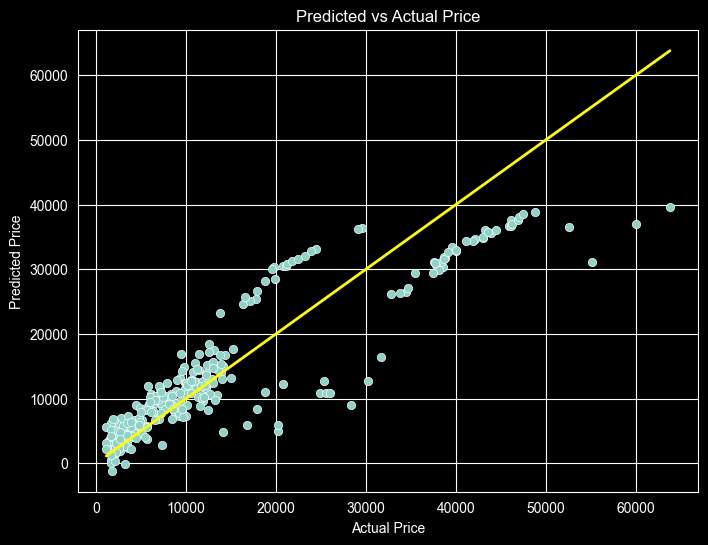

In [194]:
# Actual Price vs Predicted Price
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], c='yellow',  linewidth=2)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual Price")
plt.show()